# ... 2 ...

# Workflow Database

In [1]:
from cosim import Flow, Flowdb

* List available workflows

In [2]:
Flowdb.List()

['flow_1', 'flow_2']

* Select a workflow 

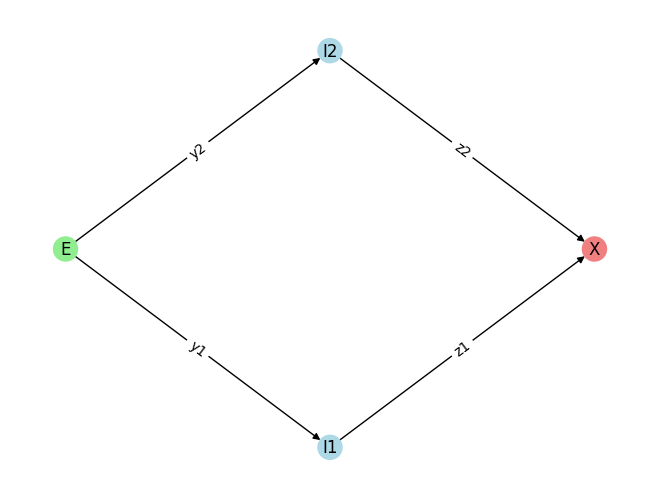

Node E:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 0.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 0.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 0.0, 'decision': None, 'subset': 1}
Node X:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 0.0, 'decision': None, 'subset': 2}
Edge ('E', 'I1'):{'data': 'y1', 'size': 0.0}
Edge ('E', 'I2'):{'data': 'y2', 'size': 0.0}
Edge ('I1', 'X'):{'data': 'z1', 'size': 0.0}
Edge ('I2', 'X'):{'data': 'z2', 'size': 0.0}


In [3]:
flow_name = 'flow_2'
flow = Flow(flow_name, **Flowdb.Get(flow_name))
flow.render()
print(flow)

* Inpect attributes

In [4]:
flow.NAME, flow.NODES, flow.ENTRY, flow.EXIT

('flow_2', ['E', 'I1', 'I2', 'X'], 'E', 'X')

In [5]:
flow.__dict__

{'graph': {},
 '_node': {'E': {'inputs': ('x',),
   'outputs': ('y1', 'y2'),
   'size': 0.0,
   'decision': None,
   'subset': 0},
  'I1': {'inputs': ('y1',),
   'outputs': ('z1',),
   'size': 0.0,
   'decision': None,
   'subset': 1},
  'I2': {'inputs': ('y2',),
   'outputs': ('z2',),
   'size': 0.0,
   'decision': None,
   'subset': 1},
  'X': {'inputs': ('z1', 'z2'),
   'outputs': ('o',),
   'size': 0.0,
   'decision': None,
   'subset': 2}},
 '_adj': {'E': {'I1': {'data': 'y1', 'size': 0.0},
   'I2': {'data': 'y2', 'size': 0.0}},
  'I1': {'X': {'data': 'z1', 'size': 0.0}},
  'I2': {'X': {'data': 'z2', 'size': 0.0}},
  'X': {}},
 '_succ': {'E': {'I1': {'data': 'y1', 'size': 0.0},
   'I2': {'data': 'y2', 'size': 0.0}},
  'I1': {'X': {'data': 'z1', 'size': 0.0}},
  'I2': {'X': {'data': 'z2', 'size': 0.0}},
  'X': {}},
 '_pred': {'E': {},
  'I1': {'E': {'data': 'y1', 'size': 0.0}},
  'I2': {'E': {'data': 'y2', 'size': 0.0}},
  'X': {'I1': {'data': 'z1', 'size': 0.0}, 'I2': {'data': 'z2

* Set task and data sizes

In [6]:
import random
flow = flow * [random.randint(5, 19) for _ in flow.nodes] # set task sizes
flow = flow / [random.randint(15, 99) for _ in flow.edges] # set data sizes


In [7]:
print(flow)

Node E:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 12.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 15.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 10.0, 'decision': None, 'subset': 1}
Node X:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 8.0, 'decision': None, 'subset': 2}
Edge ('E', 'I1'):{'data': 'y1', 'size': 99.0}
Edge ('E', 'I2'):{'data': 'y2', 'size': 23.0}
Edge ('I1', 'X'):{'data': 'z1', 'size': 47.0}
Edge ('I2', 'X'):{'data': 'z2', 'size': 96.0}


## Executing a flow

In [8]:
import os
from cosim import Executor, Kio, timestamp

pyexe = 'python'
codepath = os.path.abspath('__db__/flow_2')
datapath = os.path.join(codepath, f'data_{timestamp()}')
os.makedirs(datapath, exist_ok=True)

input_path = os.path.join(datapath, flow.nodes[flow.ENTRY]['inputs'][0])
input_value = 12 #int(input())
Kio.SavePICK(input_path, input_value)


result = Executor(
    flow=flow,
    pyexe=pyexe,
    codepath=codepath,
    datapath=datapath,
)

output_path = os.path.join(datapath, flow.nodes[flow.EXIT]['outputs'][0])
output_value = Kio.LoadPICK(output_path)

print(output_value)
result

Task E: cycles=14015083407, instructions=7957281271, elapsed=3.896723661, prefs=3.9218191349646077, datasent=[5, 21], bytes=26
Task I1: cycles=14046747957, instructions=7985198001, elapsed=3.879644709, prefs=3.8900797379901633, datasent=[5], bytes=5
Task I2: cycles=14070064170, instructions=7985419901, elapsed=5.885857835, prefs=5.896059592952952, datasent=[21], bytes=21
Task X: cycles=14322909509, instructions=8083926629, elapsed=1.888722942, prefs=1.8999434090219438, datasent=[], bytes=0
17.535898384862247


{'E': {'y1': 5,
  'y2': 21,
  '': (14015083407, 7957281271, 3.896723661, 3.9218191349646077)},
 'I1': {'z1': 5,
  '': (14046747957, 7985198001, 3.879644709, 3.8900797379901633)},
 'I2': {'z2': 21,
  '': (14070064170, 7985419901, 5.885857835, 5.896059592952952)},
 'X': {'o': 0.0,
  '': (14322909509, 8083926629, 1.888722942, 1.8999434090219438)}}